## 📦 Imports

In [1]:
import torch
from torch import nn
from torchvision import transforms

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import roc_curve, precision_recall_curve
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

## Project files
from Datasets.dataset import RARE, GreenChannelCLAHE, EndoscopyArtifactRemover
from utils import evaluate, load
from metrics import compute_metrics, get_wandb_curves

## models
from methods.ResNet import resnet50

## Loss functions
from loss import WeightedFocalLoss, HybridBCEMedicalLoss

print('✅ All imports successful')

✅ All imports successful


## ⚙️ Configuration

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device: {DEVICE}')

RARE_ROOT_PATH  = "./Datasets/RARE25-train-data"
MODEL_SAVE_PATH = "./saved_model/"
BATCH_SIZE      = 256


MODELS_TO_EVAL = [
    {
        "name":     "ResNet-WBCE+Focal",
        "filename": "ResNet-WBCE+Focal",
        "loss_fn": HybridBCEMedicalLoss(
                            pos_weight_bce=20.0,  
                            alpha_focal=0.95,     
                            gamma_focal=1.0,      
                            lambda_hybrid=0.5      
                        ),
        "model_fn": lambda: resnet50(pretrained=False),
    },
    {
        "name":     "ResNet-Focal",
        "filename": "ResNet-Focal",
        "loss_fn": WeightedFocalLoss(alpha=0.95, gamma=1.5),
        "model_fn": lambda: resnet50(pretrained=False),
    },
    {
        "name":     "ResNet-WBCE-10weighted",
        "filename": "ResNet-WBCE-10weighted",
        "loss_fn": nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0], dtype=torch.float32)),
        "model_fn": lambda: resnet50(pretrained=False),
    },
    {
        "name":     "ResNet-WBCE-20weighted",
        "filename": "ResNet-WBCE-20weighted",
        "loss_fn": nn.BCEWithLogitsLoss(pos_weight=torch.tensor([20.0], dtype=torch.float32)),
        "model_fn": lambda: resnet50(pretrained=False),
    },
]

🖥️  Device: cuda


## 🔄 Data Loaders

In [5]:
val_transforms = transforms.Compose([
    EndoscopyArtifactRemover(target_size=(224, 224)),
    GreenChannelCLAHE(clip_limit=2.0, tile_size=(8, 8)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

valid_loader = RARE(RARE_ROOT_PATH, mode='valid',
                    transform=val_transforms, mini=False)(batch_size=BATCH_SIZE)

print(f'✅ Validation loader: {len(valid_loader.dataset)} samples')

Loaded dataset with 158 'neo' (neoplasia) images and 2937 'ndbe' (nondysplastic) images.
✅ Validation loader: 618 samples


## 🛠️ Helper Functions

In [8]:
def load_and_eval(model_cfg: dict, loader, device=DEVICE):
    model = model_cfg["model_fn"]().to(device)
    load_path = MODEL_SAVE_PATH + model_cfg["filename"] + ".pth"
    model, _, _ = load(model, optimizer=None, loss_fn=None,
                       device=device, reset=False, load_path=load_path)

    wrapped_loader = tqdm(loader, desc=f'  📊 {model_cfg["name"]}', unit='batch')

    metrics, y_true, y_scores = evaluate(model, wrapped_loader,
                                         model_cfg["loss_fn"].to(device), compute_metrics,
                                         device=device)
    return metrics, y_true, y_scores



DISPLAY_KEYS = [
    "Loss", "AUROC", "AUPRC",
    "PPV@90% Recall",
    "Accuracy", "Sensitivity", "Specificity",
    "T90_TP", "T90_FP", "T90_FN",
]


FLOAT_KEYS = {"Loss", "AUROC", "AUPRC",
              "PPV@90% Recall", "Accuracy", "Sensitivity", "Specificity"}

print('✅ Helper functions ready')

✅ Helper functions ready


## 🚀 Run Evaluation on All Models

In [9]:
results = {}

for cfg in MODELS_TO_EVAL:
    display_name = cfg["name"]

    print(f'\n⏳  Evaluating  [{display_name}] ...')

    val_metrics,  val_y_true,  val_y_scores  = load_and_eval(cfg, valid_loader)

    results[display_name] = {
        'valid'    : val_metrics,
        'val_raw'  : (val_y_true,  val_y_scores),
    }
    print(f'\n   ✅  Validation  AUROC={val_metrics["AUROC"]:.4f}  '
          f'AUPRC={val_metrics["AUPRC"]:.4f}  '
          f'PPV@90={val_metrics["PPV@90% Recall"]:.4f}')

print('\n🎉  All models evaluated!')


⏳  Evaluating  [ResNet-WBCE+Focal] ...


  📊 ResNet-WBCE+Focal: 100%|██████████| 3/3 [00:33<00:00, 11.29s/batch]



   ✅  Validation  AUROC=0.9007  AUPRC=0.5665  PPV@90=0.1972

⏳  Evaluating  [ResNet-Focal] ...


  📊 ResNet-Focal: 100%|██████████| 3/3 [00:34<00:00, 11.37s/batch]



   ✅  Validation  AUROC=0.7482  AUPRC=0.1619  PPV@90=0.0686

⏳  Evaluating  [ResNet-WBCE-10weighted] ...


  📊 ResNet-WBCE-10weighted: 100%|██████████| 3/3 [00:33<00:00, 11.33s/batch]



   ✅  Validation  AUROC=0.8865  AUPRC=0.5355  PPV@90=0.1191

⏳  Evaluating  [ResNet-WBCE-20weighted] ...


  📊 ResNet-WBCE-20weighted: 100%|██████████| 3/3 [00:33<00:00, 11.19s/batch]


   ✅  Validation  AUROC=0.8180  AUPRC=0.3026  PPV@90=0.0773

🎉  All models evaluated!


## 📊 Comparison Table

In [13]:
def build_comparison_table(results: dict, split: str) -> pd.DataFrame:
    rows = []
    for model_name, splits in results.items():
        m = splits[split]
        row = {"Model": model_name}
        for k in DISPLAY_KEYS:
            if k in FLOAT_KEYS:
                row[k] = round(float(m[k]), 4)
            else:
                row[k] = int(m[k])
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Model")
    return df

def highlight_best(df: pd.DataFrame) :#-> pd.io.formats.style.Styler
    higher_is_better = [c for c in df.columns if c != "Loss"]
    lower_is_better  = ["Loss"]

    def _highlight(s, best_fn):
        is_best = s == best_fn(s)
        return [
            'background-color: #1a6b3c; color: white; font-weight: bold'
            if v else
            'background-color: #1e1e1e; color: #cccccc'
            for v in is_best
        ]

    styler = df.style
    for col in higher_is_better:
        if col in df.columns:
            styler = styler.apply(_highlight, best_fn=max, subset=[col])
    for col in lower_is_better:
        if col in df.columns:
            styler = styler.apply(_highlight, best_fn=min, subset=[col])

    return (styler
            .format({k: "{:.4f}" for k in FLOAT_KEYS if k in df.columns})
            .set_properties(**{
                'border': '1px solid #444',
                'padding': '6px 12px',
                'text-align': 'center',
            })
            .set_table_styles([
                {'selector': 'th',
                 'props': [('background-color', '#2d2d2d'),
                           ('color', '#ffffff'),
                           ('font-weight', 'bold'),
                           ('padding', '8px 12px'),
                           ('border', '1px solid #555')]},
                {'selector': 'tr:hover td',
                 'props': [('background-color', '#2a2a2a')]},
            ])
    )
# ─── نمایش ─────────────────────────────────────────────────────────────────
print('=' * 55)
print('                 VALIDATION SET')
print('=' * 55)
val_df = build_comparison_table(results, 'valid')
display(highlight_best(val_df))


                 VALIDATION SET


,Loss,AUROC,AUPRC,PPV@90% Recall,Accuracy,Sensitivity,Specificity,T90_TP,T90_FP,T90_FN
Model,,,,,,,,,,
ResNet-WBCE+Focal,0.4255,0.9007,0.5665,0.1972,0.9159,0.7742,0.9233,28,114,3
ResNet-Focal,0.0210,0.7482,0.1619,0.0686,0.7443,0.7097,0.7462,28,380,3
ResNet-WBCE-10weighted,0.5775,0.8865,0.5355,0.1191,0.9061,0.6452,0.9199,28,207,3
ResNet-WBCE-20weighted,1.3735,0.8180,0.3026,0.0773,0.9353,0.1935,0.9744,28,334,3


## 📈 ROC & PR Curves 

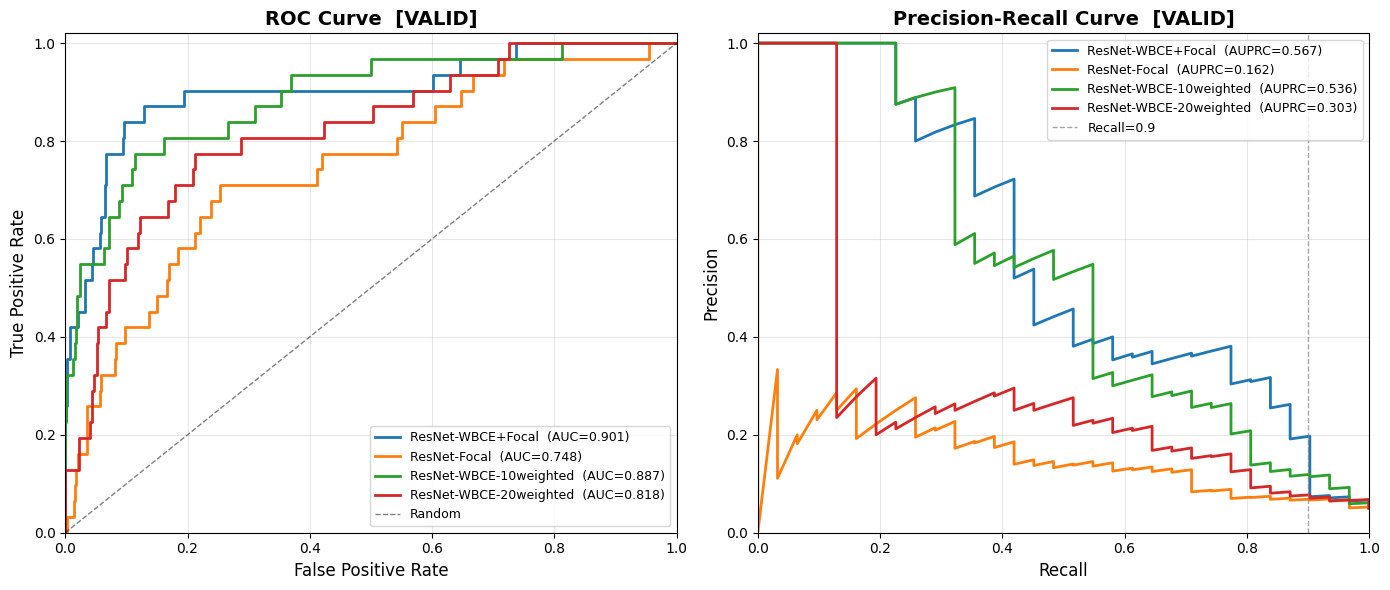

In [14]:
def plot_curves(results: dict, split: str = 'test') -> None:
    n_models = len(results)
    colors   = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_roc, ax_pr = axes

    raw_key = 'val_raw' if split == 'valid' else 'test_raw'

    for idx, (model_name, data) in enumerate(results.items()):
        y_true, y_scores = data[raw_key]
        color = colors[idx % len(colors)]

        auroc = data[split]['AUROC']
        auprc = data[split]['AUPRC']

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        ax_roc.plot(fpr, tpr, color=color, lw=2,
                    label=f"{model_name}  (AUC={auroc:.3f})")

        # PR
        prec, rec, _ = precision_recall_curve(y_true, y_scores)
        ax_pr.plot(rec, prec, color=color, lw=2,
                   label=f"{model_name}  (AUPRC={auprc:.3f})")

    # ─── ROC ───
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate',  fontsize=12)
    ax_roc.set_title(f'ROC Curve  [{split.upper()}]', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(True, alpha=0.3)

    # ─── PR ────
    ax_pr.axvline(x=0.9, color='gray', linestyle='--', lw=1, alpha=0.7, label='Recall=0.9')
    ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.02])
    ax_pr.set_xlabel('Recall',    fontsize=12)
    ax_pr.set_ylabel('Precision', fontsize=12)
    ax_pr.set_title(f'Precision-Recall Curve  [{split.upper()}]', fontsize=14, fontweight='bold')
    ax_pr.legend(loc='upper right', fontsize=9)
    ax_pr.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f'curves_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()
    # print(f'💾  Saved  →  curves_{split}.png')


plot_curves(results, split='valid')

## 🗂️ Confusion Matrix @ T90 Threshold

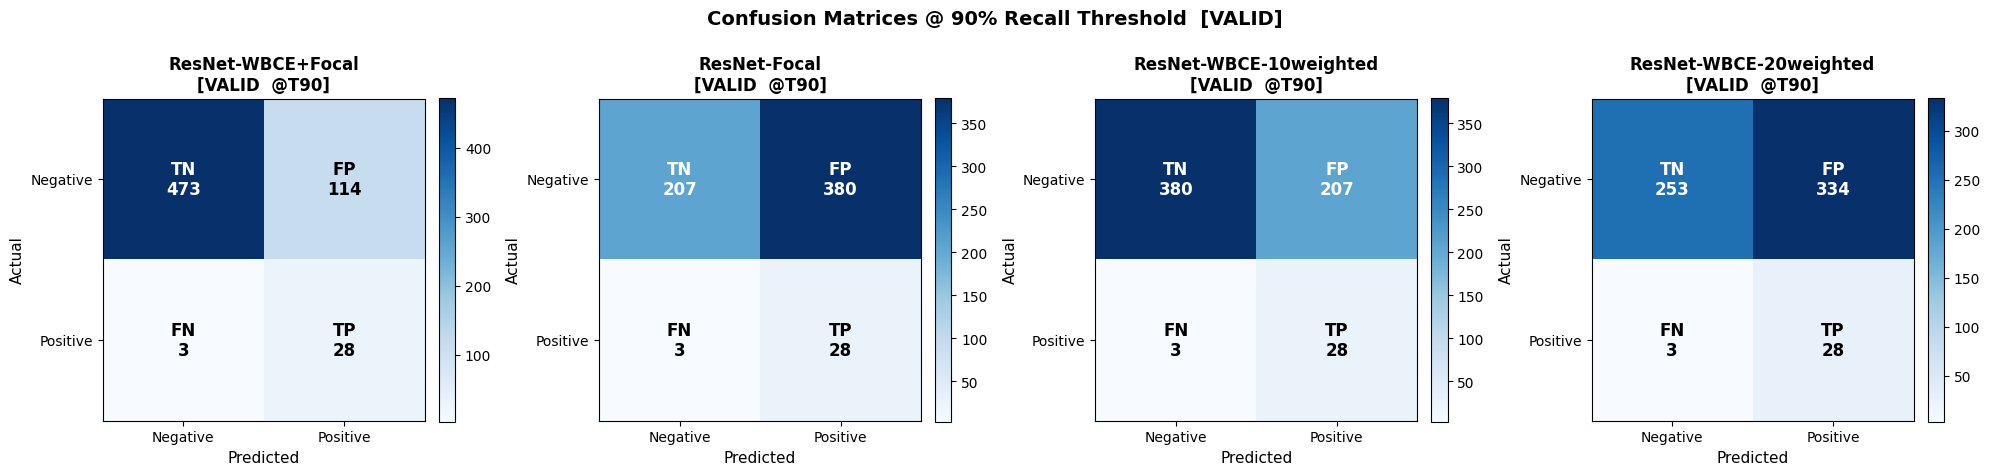

In [15]:
def plot_confusion_matrices(results: dict, split: str = 'test') -> None:
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]

    for ax, (model_name, data) in zip(axes, results.items()):
        m   = data[split]
        tp  = m['T90_TP']; fn = m['T90_FN']; fp = m['T90_FP']
        tn  = int(data[split].get('T90_TN', 0))  

        if tn == 0:
            raw_key = 'val_raw' if split == 'valid' else 'test_raw'
            y_true, y_scores = data[raw_key]
            thresh = m['T90_Threshold']
            y_pred = (y_scores >= thresh).astype(int)
            tn = int(np.sum((y_pred == 0) & (y_true == 0)))

        cm = np.array([[tn, fp], [fn, tp]])

        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        labels = ['Negative', 'Positive']
        ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Predicted',  fontsize=11)
        ax.set_ylabel('Actual',     fontsize=11)
        ax.set_title(f'{model_name}\n[{split.upper()}  @T90]',
                     fontsize=12, fontweight='bold')

        cell_labels = [[f'TN\n{tn}', f'FP\n{fp}'],
                       [f'FN\n{fn}', f'TP\n{tp}']]
        thresh_color = cm.max() / 2
        for i in range(2):
            for j in range(2):
                color = 'white' if cm[i, j] > thresh_color else 'black'
                ax.text(j, i, cell_labels[i][j],
                        ha='center', va='center',
                        color=color, fontsize=12, fontweight='bold')

    plt.suptitle(f'Confusion Matrices @ 90% Recall Threshold  [{split.upper()}]',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    # plt.savefig(f'confusion_matrices_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()
    # print(f'💾  Saved  →  confusion_matrices_{split}.png')


plot_confusion_matrices(results, split='valid')

## 🏆 Radar Chart

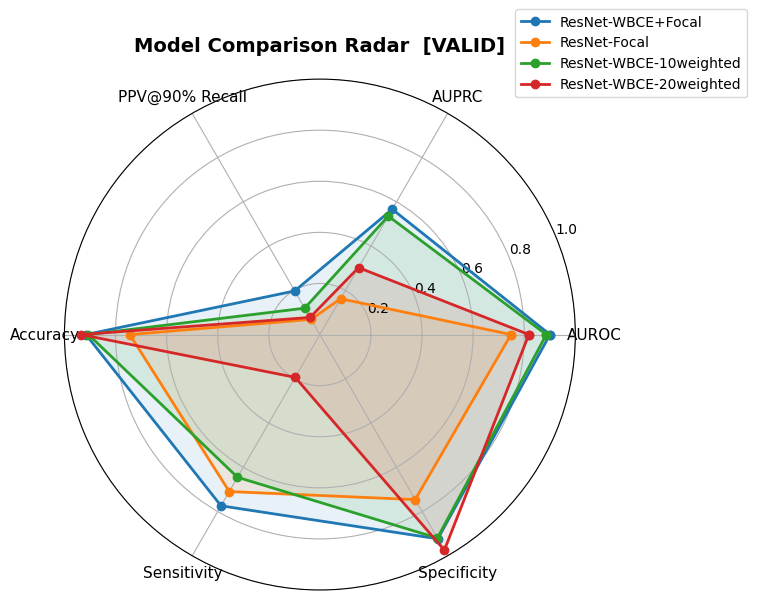

In [16]:
def plot_radar(results: dict, split: str = 'test') -> None:
    radar_keys = ["AUROC", "AUPRC", "PPV@90% Recall",
                  "Accuracy", "Sensitivity", "Specificity"]
    n_metrics  = len(radar_keys)
    angles     = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles    += angles[:1]          

    fig, ax = plt.subplots(figsize=(8, 8),
                           subplot_kw=dict(polar=True))
    colors  = plt.cm.tab10.colors

    for idx, (model_name, data) in enumerate(results.items()):
        m      = data[split]
        values = [float(m[k]) for k in radar_keys]
        values += values[:1]

        color = colors[idx % len(colors)]
        ax.plot(angles, values, 'o-', lw=2, color=color, label=model_name)
        ax.fill(angles, values, alpha=0.10, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_keys, size=11)
    ax.set_ylim(0, 1)
    ax.set_title(f'Model Comparison Radar  [{split.upper()}]',
                 size=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True)

    plt.tight_layout()
    # plt.savefig(f'radar_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()
    # print(f'💾  Saved  →  radar_{split}.png')


plot_radar(results, split='valid')

## 🔍 Single-Model Deep Dive


  🔍  ResNet-WBCE+Focal  [VALID]


,Value
Metric,
Loss,0.0523
AUROC,0.9006
AUPRC,0.5665
PPV@90% Recall,0.1958
Accuracy,0.9159
Sensitivity,0.7742
Specificity,0.9233
T90_TP,28
T90_FP,115


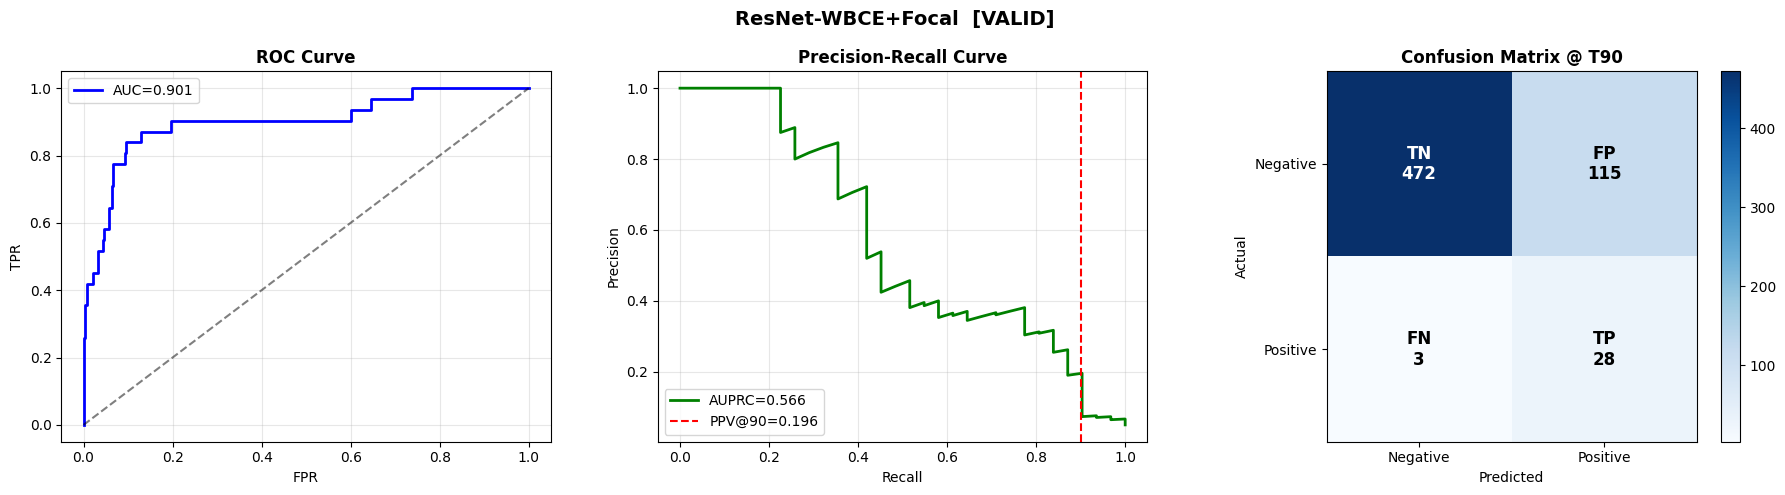

In [ ]:
def deep_dive(model_name: str, split: str = 'test') -> None:
    if model_name not in results:
        print(f'❌  Model "{model_name}" not found. Available: {list(results.keys())}')
        return

    data    = results[model_name]
    m       = data[split]
    raw_key = 'val_raw' if split == 'valid' else 'test_raw'
    y_true, y_scores = data[raw_key]
    thresh  = m['T90_Threshold']

    print(f'\n{"=" * 55}')
    print(f'  🔍  {model_name}  [{split.upper()}]')
    print(f'{"=" * 55}')

    metric_rows = [(k, f"{float(m[k]):.4f}" if k in FLOAT_KEYS else int(m[k]))
                   for k in DISPLAY_KEYS]
    metric_rows.append(("T90_Threshold", f"{float(m['T90_Threshold']):.4f}"))
    display(pd.DataFrame(metric_rows, columns=["Metric", "Value"]).set_index("Metric"))

    # ─── Plots ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={m["AUROC"]:.3f}')
    axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_scores)
    axes[1].plot(rec, prec, 'g-', lw=2, label=f'AUPRC={m["AUPRC"]:.3f}')
    axes[1].axvline(x=0.9, color='red', linestyle='--', lw=1.5,
                    label=f'PPV@90={m["PPV@90% Recall"]:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Confusion Matrix
    y_pred = (y_scores >= thresh).astype(int)
    tn     = int(np.sum((y_pred == 0) & (y_true == 0)))
    tp     = int(m['T90_TP']); fp = int(m['T90_FP']); fn = int(m['T90_FN'])
    cm     = np.array([[tn, fp], [fn, tp]])
    im     = axes[2].imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    labels = ['Negative', 'Positive']
    axes[2].set_xticks([0,1]); axes[2].set_xticklabels(labels)
    axes[2].set_yticks([0,1]); axes[2].set_yticklabels(labels)
    axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
    axes[2].set_title(f'Confusion Matrix @ T90', fontweight='bold')
    cell_lbs = [[f'TN\n{tn}',f'FP\n{fp}'],[f'FN\n{fn}',f'TP\n{tp}']]
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            axes[2].text(j, i, cell_lbs[i][j],
                        ha='center', va='center',
                        color=color, fontsize=12, fontweight='bold')

    plt.suptitle(f'{model_name}  [{split.upper()}]',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    safe_name = model_name.replace('/', '_').replace('+', '-')
    plt.savefig(f'deepdive_{safe_name}_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ─── مثال استفاده — اسم مدل رو عوض کن ───────────────────────────────────────
deep_dive("ResNet-WBCE+Focal", split='valid')